In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set professional visualization styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150 

# --- DIRECT ABSOLUTE PATH FOR SAVING CHARTS ---
# This finds your project root and creates the exact path to /images/eda
PROJECT_ROOT = Path(os.getcwd()).parent
EDA_IMAGE_DIR = PROJECT_ROOT / "images" / "eda"
SAVE_PATH = str(EDA_IMAGE_DIR.resolve())

# Create the folder if it doesn't exist
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"✓ Charts will be saved directly to: {SAVE_PATH}")

# --- DATABASE CONNECTION ---
connection_string = (
    "mssql+pyodbc://@localhost/retail_warehouse"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&TrustServerCertificate=yes"
    "&Trusted_Connection=yes"
)

engine = create_engine(connection_string, fast_executemany=True)

# Load all tables
print("Loading data from SQL Server...")
customers = pd.read_sql("SELECT * FROM stg_customers", engine)
orders = pd.read_sql("SELECT * FROM stg_orders", engine)
items = pd.read_sql("SELECT * FROM stg_order_items", engine)
payments = pd.read_sql("SELECT * FROM stg_order_payments", engine)
reviews = pd.read_sql("SELECT * FROM stg_order_reviews", engine)
products = pd.read_sql("SELECT * FROM stg_products", engine)
sellers = pd.read_sql("SELECT * FROM stg_sellers", engine)

print("Data loaded successfully!")

✓ Charts will be saved directly to: D:\Data Analyst\Enterprise-Retail-Command-Centre\images\eda
Loading data from SQL Server...
Data loaded successfully!


In [2]:
# --- ORDERS TABLE PROFILING ---
print("=" * 50)
print("ORDERS TABLE PROFILING")
print("=" * 50)
print(f"Total Rows: {len(orders):,}")
print("\nFirst 5 Rows:")
display(orders.head())

print("\nMissing Values in Orders:")
print(orders.isnull().sum())

# --- TABLE RELATIONSHIP VERIFICATION ---
print("\n" + "=" * 50)
print("TABLE RELATIONSHIPS (Unique Keys)")
print("=" * 50)
print(f"Unique order_ids in Orders:   {orders['order_id'].nunique():,}")
print(f"Unique order_ids in Items:    {items['order_id'].nunique():,}")
print(f"Unique order_ids in Payments: {payments['order_id'].nunique():,}")
print(f"Unique order_ids in Reviews:  {reviews['order_id'].nunique():,}")
print(f"Unique customer_ids:          {customers['customer_id'].nunique():,}")
print(f"Unique product_ids:           {products['product_id'].nunique():,}")

ORDERS TABLE PROFILING
Total Rows: 99,441

First 5 Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Missing Values in Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

TABLE RELATIONSHIPS (Unique Keys)
Unique order_ids in Orders:   99,441
Unique order_ids in Items:    98,666
Unique order_ids in Payments: 99,440
Unique order_ids in Reviews:  98,167
Unique customer_ids:          99,441
Unique product_ids:           32,951


✓ Saved: D:\Data Analyst\Enterprise-Retail-Command-Centre\images\eda\01_monthly_order_trend.png


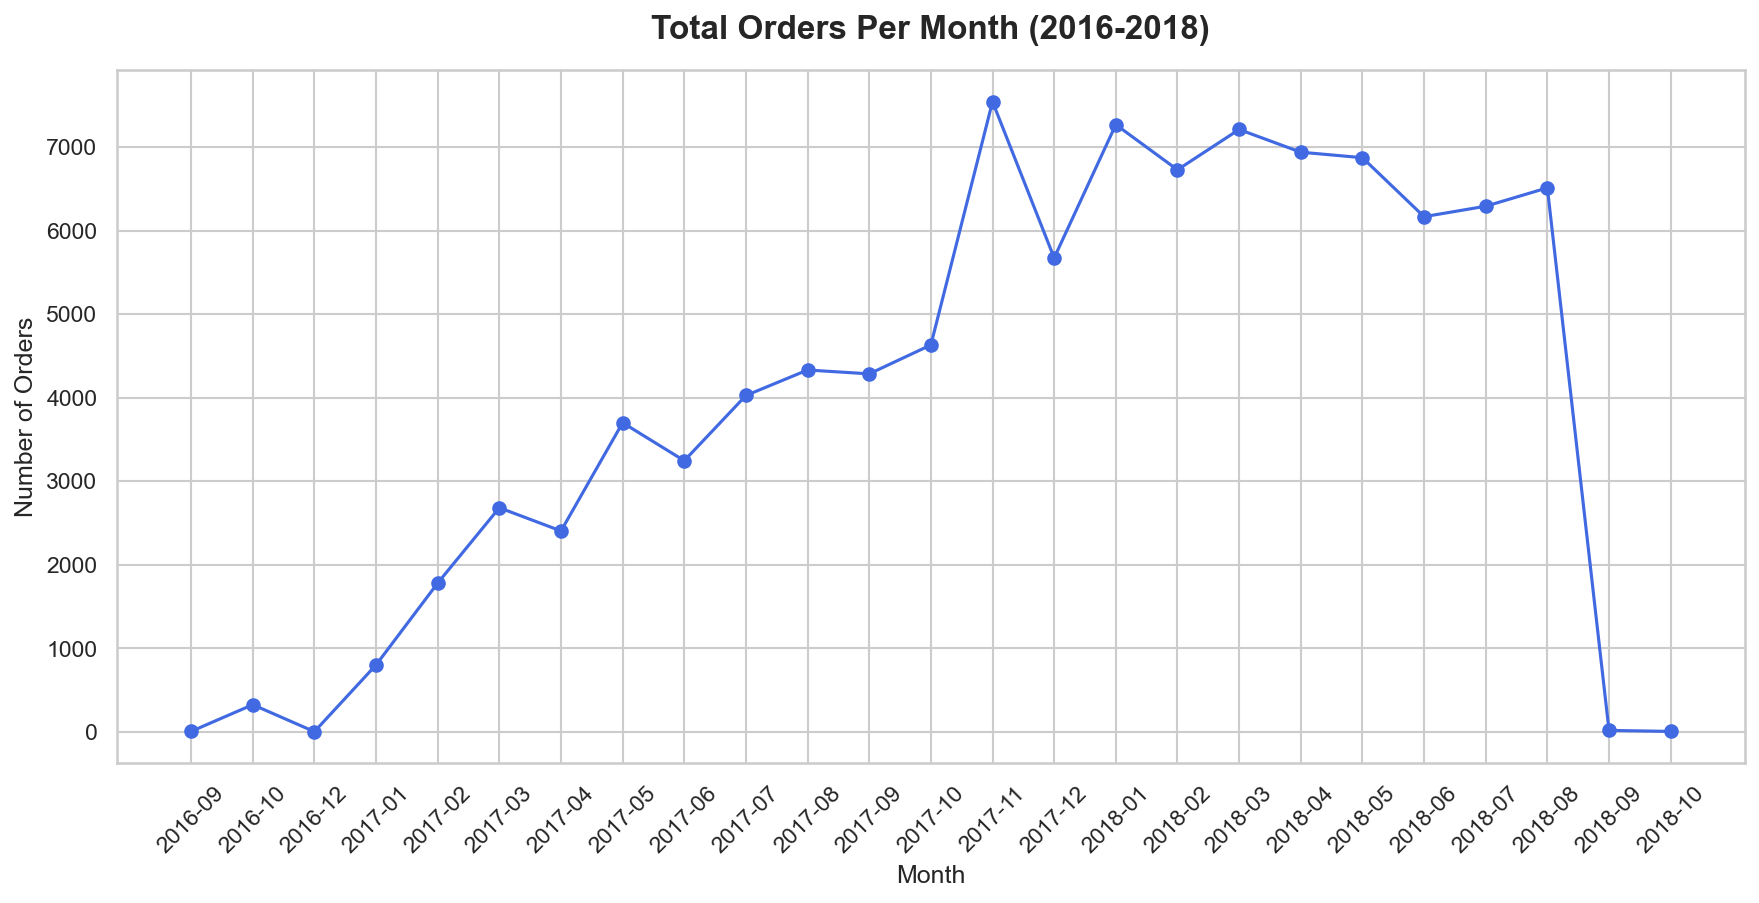

✓ Saved: D:\Data Analyst\Enterprise-Retail-Command-Centre\images\eda\02_order_status_distribution.png


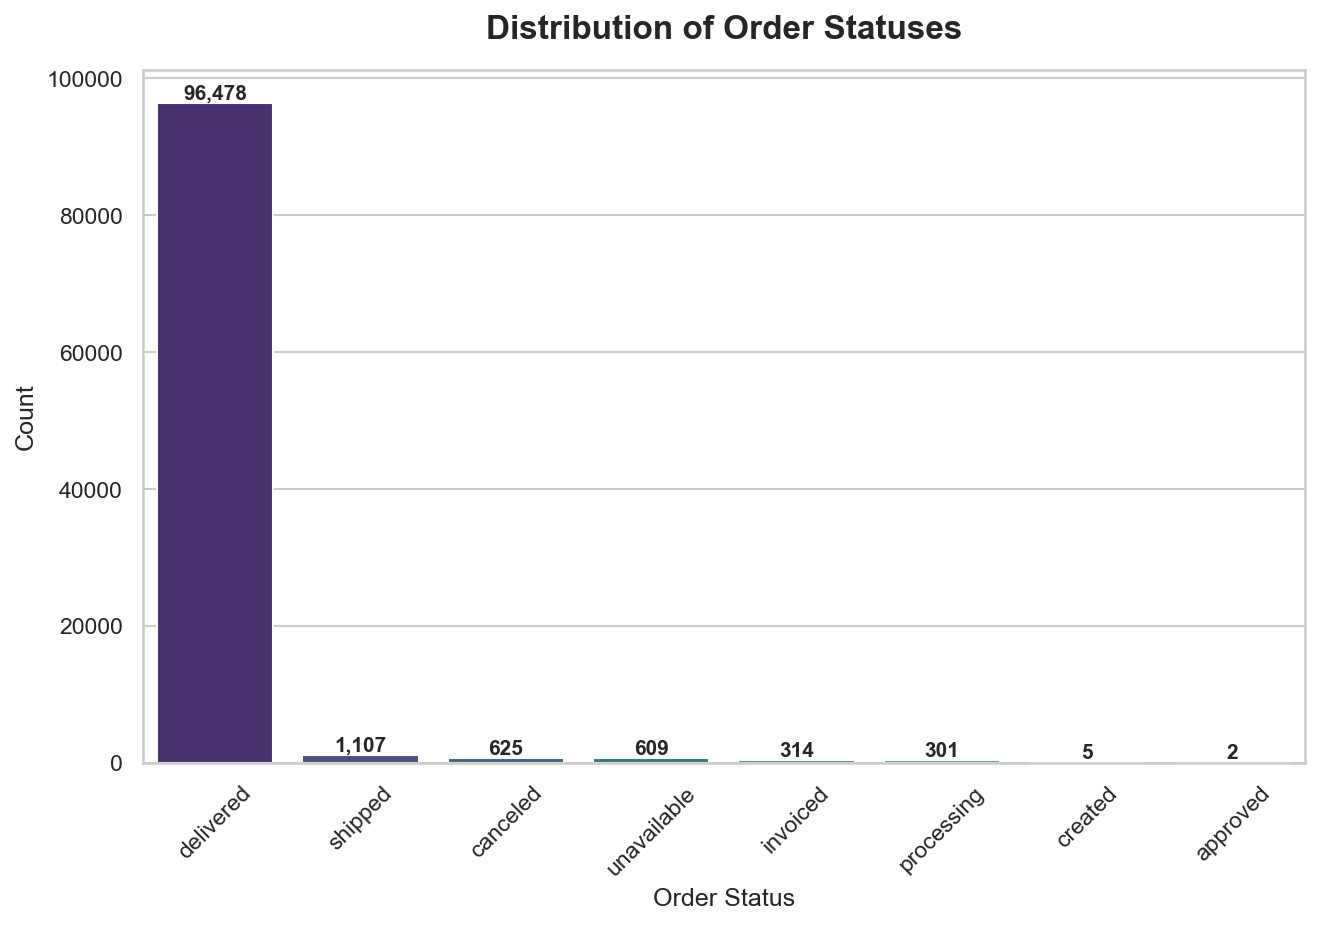

✓ Saved: D:\Data Analyst\Enterprise-Retail-Command-Centre\images\eda\03_payment_type_distribution.png


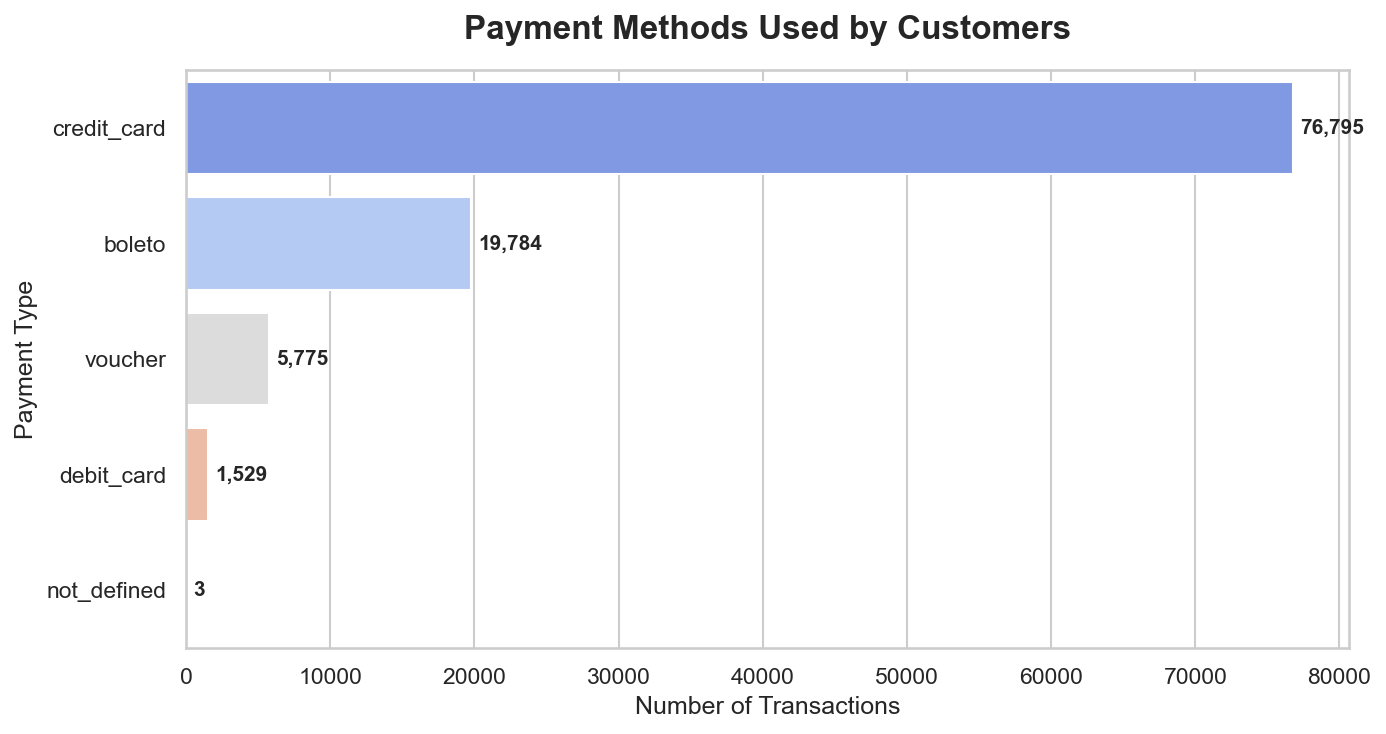

In [3]:
# CHART 1: Monthly Order Trend
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('order_month').size()

plt.figure(figsize=(14, 6))
plt.plot(monthly_orders.index.astype(str), monthly_orders.values, marker='o', color='royalblue')
plt.title('Total Orders Per Month (2016-2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)

chart1_path = os.path.join(SAVE_PATH, "01_monthly_order_trend.png")
plt.savefig(chart1_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {chart1_path}")
plt.show()

# CHART 2: Order Status Distribution
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x=status_counts.index, y=status_counts.values, hue=status_counts.index, palette='viridis', legend=False)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Distribution of Order Statuses', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

chart2_path = os.path.join(SAVE_PATH, "02_order_status_distribution.png")
plt.savefig(chart2_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {chart2_path}")
plt.show()

# CHART 3: Payment Type Breakdown
payment_counts = payments['payment_type'].value_counts()

plt.figure(figsize=(10, 5))
ax2 = sns.barplot(y=payment_counts.index, x=payment_counts.values, hue=payment_counts.index, palette='coolwarm', legend=False)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width() + 500, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, fontweight='bold')
plt.title('Payment Methods Used by Customers', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Payment Type', fontsize=12)

chart3_path = os.path.join(SAVE_PATH, "03_payment_type_distribution.png")
plt.savefig(chart3_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {chart3_path}")
plt.show()

C:\Users\Yash Rathi\AppData\Local\Temp\ipykernel_24984\792490366.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis', ax=ax)


✓ Chart saved to: ../../images/eda\02_order_status_distribution.png


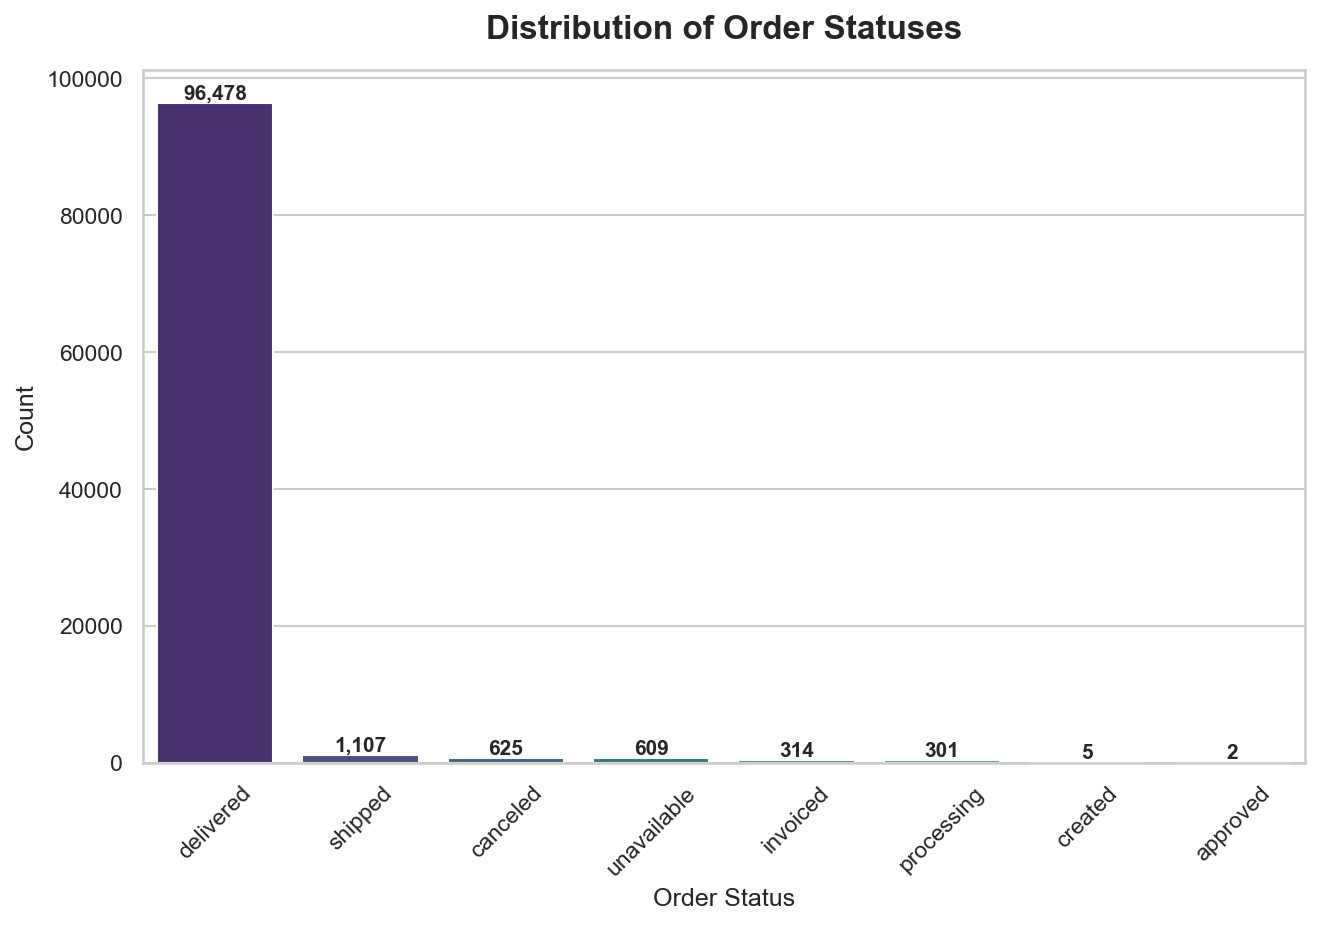